In [39]:
# All of the imports
# all the imports
import torch
from grn_inference_msc.vae_model.vae_model import Model, ModelConfig
from grn_inference_msc.vae_model.constants import ProbabilityDistributions
from grn_inference_msc.vae_model.data import Dataset
from utils import float_to_unique_string
from grn_inference_msc.vae_model.loss import VAEGaussianLikelihoodLoss
from tqdm import trange
from benchmark import stats_pipeline
import numpy as np
import matplotlib.pyplot as plt
from basic_algorithms import least_squares, zscore

In [ ]:
# Parameters for the data i will use when running this notebook
n_genes = 100
n_reps = 3
SNR = 0.1

In [65]:
# Parameters for the models
dim_latent = 4
grn_layer_type = 'before'
encoder_hidden_dimensions = [256]
decoder_hidden_dimensions = [256]
lr = 0.001
beta = 1
alpha = 1
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')


In [66]:
dataset = Dataset(f'../hyperparameter_optimization/data/dataset_{n_genes}g_{n_reps}r_SNR{float_to_unique_string(SNR)}')
X, P = dataset.get_batch_normalized()

model_config = ModelConfig(
    dim_in=n_genes*n_reps,
    dim_latent=dim_latent,
    n_genes=n_genes,
    grn_layer_type=grn_layer_type,
    likelihood_distribution=ProbabilityDistributions.GAUSSIAN,
    encoder_hidden_dimensions=encoder_hidden_dimensions,
    decoder_hidden_dimensions=decoder_hidden_dimensions
)
model = Model(model_config)

# Set up the training
optimizer_no_P = torch.optim.Adam(model.parameters(), lr=lr)
model_criterion = VAEGaussianLikelihoodLoss(alpha=alpha, beta=beta)

In [ ]:
# Start by calculating the starting loss
with torch.no_grad():
    model.eval()
    mu, mu_latent, logvar_latent = model(X.to(device))
    loss = model_criterion(X.to(device), mu, mu_latent, logvar_latent, model.get_A())
    print (f'Starting loss: {loss.item()}')


# The training loop

model.train()

# Monitoring the stats
AUPRs = []
AUROCs = []
losses = []

EPOCHS = trange(3000, desc='Training model')
for e in EPOCHS:
    optimizer_no_P.zero_grad()
    X, P = dataset.get_batch_normalized()
    mu, mu_latent, logvar_latent = model(X.to(device))
    loss = model_criterion(X.to(device), mu, mu_latent, logvar_latent, model.get_A())

    loss.backward()
    optimizer_no_P.step()
    EPOCHS.set_postfix(loss=loss.item())

    AUPR, AUROC, stats = stats_pipeline(model.get_A().cpu().detach().numpy(), np.abs(np.sign((dataset.get_A().numpy()))))

    losses.append(loss.item())
    AUPRs.append(AUPR)
    AUROCs.append(AUROC)

Starting loss: 435.5819091796875


Training model: 100%|██████████| 3000/3000 [00:23<00:00, 125.99it/s, loss=293]


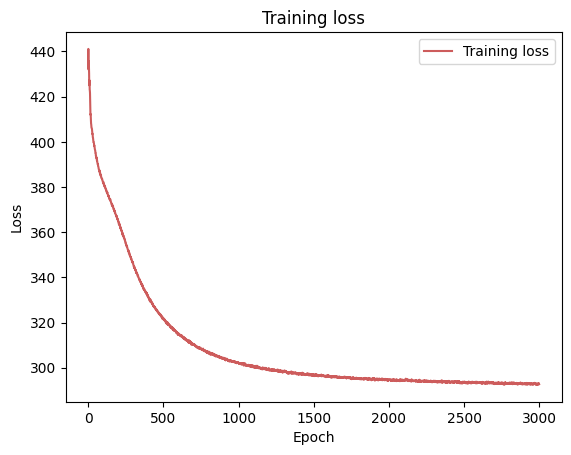

ValueError: v cannot be empty

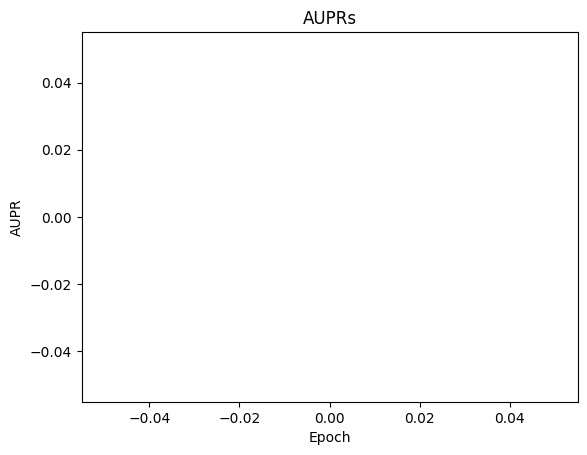

In [68]:
# Plotting the loss, aurocs and auprs
plt.title('Training loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.plot(losses, color='indianred', label='Training loss')
plt.legend()
plt.show()

plt.title('AUPRs')
plt.xlabel('Epoch')
plt.ylabel('AUPR')
plt.plot(AUPRs, color='indianred', label='AUPR smoothed')
plt.plot([x + 25 for x in range(2951)], np.convolve(AUPRs, np.ones(50)/50, mode='valid'), color='royalblue', label='AUPR smoothed')
plt.legend
plt.show()

plt.title('AUROCs')
plt.xlabel('Epoch')
plt.ylabel('AUROC')
plt.plot(AUROCs, color='indianred', label='AUROC')
plt.plot([x + 25 for x in range(2951)], np.convolve(AUROCs, np.ones(50)/50, mode='valid'), color='royalblue', label='AUROC smoothed')
plt.legend()
plt.show()

tensor(1.7532, device='cuda:0', grad_fn=<SumBackward0>)


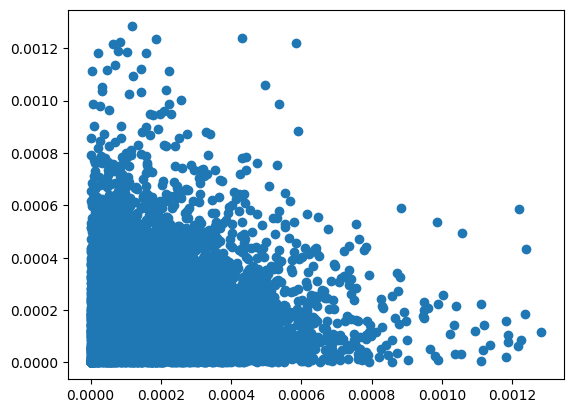

In [70]:
print (model.get_A().abs().sum())
plt.scatter(model.get_A().abs().flatten().detach().cpu().numpy(), model.get_A().abs().T.flatten().detach().cpu().numpy())
